In [3]:
!pip install arch
from arch import arch_model

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

In [90]:
nifty_50_data=yf.download("^NSEI",start='2018-01-01',end='2026-06-01')



[*********************100%***********************]  1 of 1 completed


In [129]:
nifty_close=nifty_50_data["Close"].copy()
nifty_close.rename(columns={"^NSEI":"CLOSE"},inplace=True)
nifty_close["Daily Return"]=np.log(nifty_close["CLOSE"]).diff()*100
nifty_close.dropna(inplace=True)

print(len(nifty_close))

2069


In [131]:
model=arch_model(nifty_close["Daily Return"],vol="Garch",p=1,q=1,dist="studentsT")
results=model.fit()


Iteration:      1,   Func. Count:      7,   Neg. LLF: 163396.35390257905
Iteration:      2,   Func. Count:     17,   Neg. LLF: 71958.67885007345
Iteration:      3,   Func. Count:     26,   Neg. LLF: 2810.718181988169
Iteration:      4,   Func. Count:     35,   Neg. LLF: 2884.453846550237
Iteration:      5,   Func. Count:     43,   Neg. LLF: 2657.229097013806
Iteration:      6,   Func. Count:     50,   Neg. LLF: 2640.5887980114703
Iteration:      7,   Func. Count:     56,   Neg. LLF: 2640.586271815233
Iteration:      8,   Func. Count:     62,   Neg. LLF: 2640.5861840631255
Iteration:      9,   Func. Count:     68,   Neg. LLF: 2640.58618347007
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2640.58618347007
            Iterations: 9
            Function evaluations: 68
            Gradient evaluations: 9


In [104]:
print( results.summary)


<bound method ARCHModelResult.summary of                         Constant Mean - GARCH Model Results                         
Dep. Variable:                 Daily Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2640.59
Distribution:      Standardized Student's t   AIC:                           5291.17
Method:                  Maximum Likelihood   BIC:                           5319.35
                                              No. Observations:                 2069
Date:                      Wed, Jun 17 2026   Df Residuals:                     2068
Time:                              16:18:50   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------

In [105]:
results.conditional_volatility

Date
2018-01-03    0.671927
2018-01-04    0.650588
2018-01-05    0.652528
2018-01-08    0.648521
2018-01-09    0.652699
                ...   
2026-05-22    0.809369
2026-05-25    0.775559
2026-05-26    0.842151
2026-05-27    0.823121
2026-05-29    0.786046
Name: cond_vol, Length: 2069, dtype: float64

In [134]:
results_2.conditional_volatility

Date
2018-01-03    0.665041
2018-01-04    0.637277
2018-01-05    0.619163
2018-01-08    0.600597
2018-01-09    0.586120
                ...   
2026-05-22    0.882267
2026-05-25    0.834386
2026-05-26    0.817731
2026-05-27    0.842063
2026-05-29    0.803362
Name: cond_vol, Length: 2069, dtype: float64

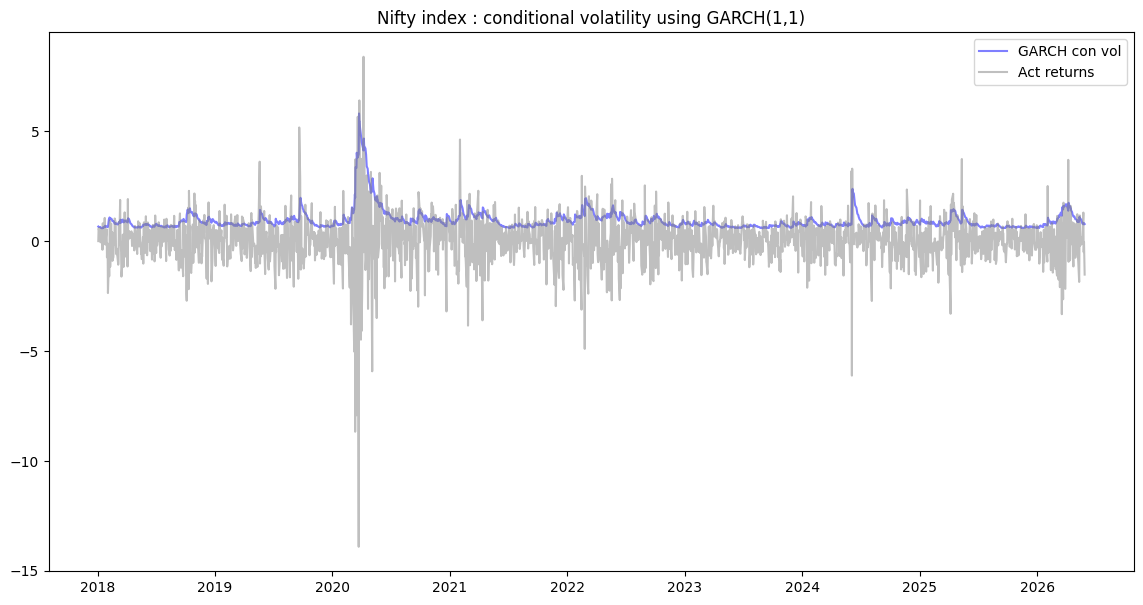

In [116]:
plt.figure(figsize=(14,7))
plt.plot(results.conditional_volatility,color='blue',label='GARCH con vol',alpha=0.5)
plt.plot(nifty_close['Daily Return'],color='grey',label='Act returns',alpha=0.5)
plt.title("Nifty index : conditional volatility using GARCH(1,1)")
plt.legend()
plt.show()

In [133]:
model_2=arch_model(nifty_close["Daily Return"],vol="Egarch",p=1,o=1,q=1,dist="studentsT")
results_2=model_2.fit()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 185104.5376873556
Iteration:      2,   Func. Count:     19,   Neg. LLF: 110803.74601136766
Iteration:      3,   Func. Count:     29,   Neg. LLF: 88908.83693831126
Iteration:      4,   Func. Count:     40,   Neg. LLF: 45878.5259350696
Iteration:      5,   Func. Count:     51,   Neg. LLF: 3231.9907151767893
Iteration:      6,   Func. Count:     61,   Neg. LLF: 2628.3249202201646
Iteration:      7,   Func. Count:     69,   Neg. LLF: 2616.589742283175
Iteration:      8,   Func. Count:     76,   Neg. LLF: 2616.460851624532
Iteration:      9,   Func. Count:     83,   Neg. LLF: 2616.4479797573827
Iteration:     10,   Func. Count:     90,   Neg. LLF: 2616.4477228670826
Iteration:     11,   Func. Count:     97,   Neg. LLF: 2616.4477194262813
Iteration:     12,   Func. Count:    103,   Neg. LLF: 2616.4477194262795
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2616.4477194262813
            Iteration

In [135]:
print(results_2.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                 Daily Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -2616.45
Distribution:      Standardized Student's t   AIC:                           5244.90
Method:                  Maximum Likelihood   BIC:                           5278.70
                                              No. Observations:                 2069
Date:                      Wed, Jun 17 2026   Df Residuals:                     2068
Time:                              18:13:04   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

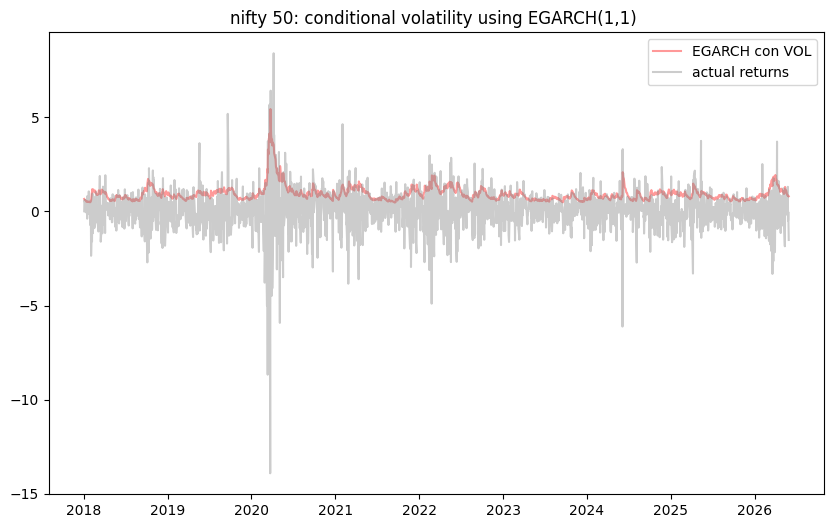

In [136]:
plt.figure(figsize=(10,6))
plt.plot(results_2.conditional_volatility,label="EGARCH con VOL",alpha=0.4,color="red")
plt.plot(nifty_close["Daily Return"],label="actual returns",alpha=0.4,color="grey")
plt.title("nifty 50: conditional volatility using EGARCH(1,1) ")
plt.legend()
plt.show()


In [155]:
nifty_close["GARCH variance"]=results.conditional_volatility**2
nifty_close["EGARCH variance"]=results_2.conditional_volatility**2
parameters_garch = results.params
omega_g = parameters_garch["omega"]
alpha_g = parameters_garch["alpha[1]"]
beta_g = parameters_garch["beta[1]"]
log_var_garch = omega_g / (1 - alpha_g - beta_g)
nifty_close["GARCH_Regime"] = np.where(
    nifty_close["GARCH variance"] > (2 * log_var_garch),
    "Extreme Vol",
    np.where(nifty_close["GARCH variance"] > log_var_garch, "High Vol", "Low Vol"),
)
print(nifty_close['GARCH variance'].value_counts())

GARCH variance
0.451486    1
0.423265    1
0.425793    1
0.420580    1
0.426017    1
           ..
0.655078    1
0.601491    1
0.709218    1
0.677529    1
0.617868    1
Name: count, Length: 2069, dtype: int64


In [156]:
parameters_egarch = results_2.params
omega_e = parameters_egarch["omega"]
beta_e = parameters_egarch["beta[1]"]
log_var_egarch = np.exp(omega_e / (1 - beta_e))

nifty_close["EGARCH_Regime"] = np.where(
    nifty_close["EGARCH variance"] > (2 * log_var_egarch),
    "Extreme Vol",
    np.where(nifty_close["EGARCH variance"] >log_var_egarch, "High Vol", "Low Vol"),
)
print("GARCH Regime Breakdown (Days):")
print(nifty_close["GARCH_Regime"].value_counts())

GARCH Regime Breakdown (Days):
GARCH_Regime
Low Vol        1444
High Vol        466
Extreme Vol     159
Name: count, dtype: int64


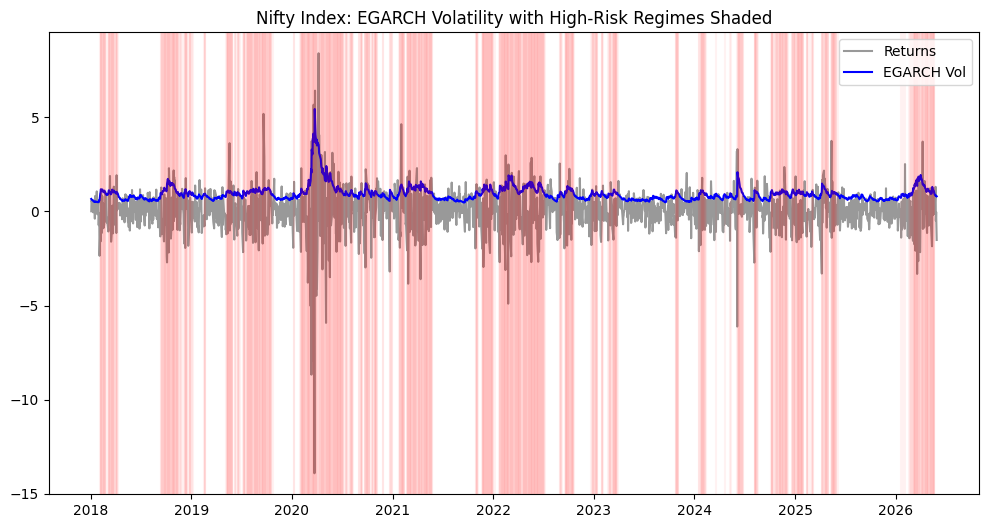

In [157]:
plt.figure(figsize=(12, 6))
plt.plot(
    nifty_close.index,
    nifty_close["Daily Return"],
    color="black",
    alpha=0.4,
    label="Returns",
)
plt.plot(
    nifty_close.index,
    results_2.conditional_volatility,
    color="blue",
    label="EGARCH Vol",
)
high_vol_dates = nifty_close[nifty_close["EGARCH variance"] > log_var_egarch].index
for date in high_vol_dates:
    plt.axvline(x=date, color="red", alpha=0.05, ymin=0, ymax=1)
plt.title("Nifty Index: EGARCH Volatility with High-Risk Regimes Shaded")
plt.legend()
plt.show()

In [166]:
fitted_index = results_2.conditional_volatility.index
regime_df = pd.DataFrame(index=fitted_index)
regime_df["Daily_Return"] = nifty_close.loc[fitted_index, "Daily Return"]
regime_df["EGARCH_Vol"] = results_2.conditional_volatility
regime_df["EGARCH_Var"] = regime_df["EGARCH_Vol"] ** 2
omega_e = results_2.params["omega"]
beta_e = results_2.params["beta[1]"]
log_var_egarch = np.exp(omega / (1 - beta))
VL_vol_threshold = np.sqrt(log_var_egarch)
regime_df["High_Vol"] = regime_df["EGARCH_Var"] > log_var_egarch
regime_df["Extreme_Vol"] = regime_df["EGARCH_Var"] > (2 * log_var_egarch)
high_vol_periods = regime_df[regime_df["High_Vol"]]
extreme_vol_periods = regime_df[regime_df["Extreme_Vol"]]
print(f"Structural Volatility Floor Baseline (Standard Deviation): {VL_vol_threshold:.2f}%")
print(f"Total trading days in a High Volatility State: {len(high_vol_periods)}")
print(f"Total trading days in an Extreme Crisis State: {len(extreme_vol_periods)}")

Structural Volatility Floor Baseline (Standard Deviation): 0.91%
Total trading days in a High Volatility State: 854
Total trading days in an Extreme Crisis State: 209


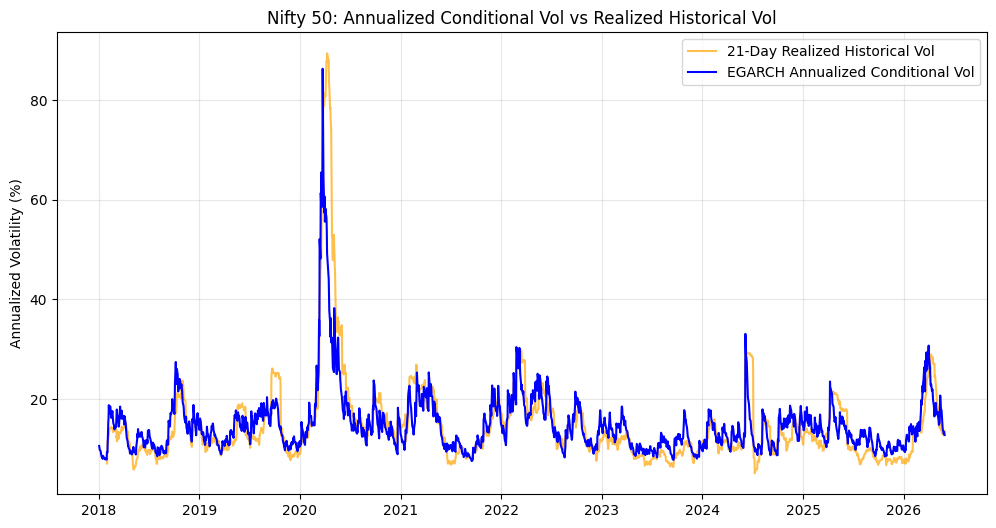

In [162]:
regime_df["Annualized_Conditional_Vol"] = (
    results_2.conditional_volatility * np.sqrt(252))
regime_df["Realized_Vol_21d"] = (
    regime_df["Daily_Return"].rolling(window=21).std() * np.sqrt(252))

regime_df["Realized_Vol_21d"] = (
    regime_df["Daily_Return"].rolling(window=21).std() * np.sqrt(252))
plt.figure(figsize=(12, 6))
plt.plot(
    regime_df.index,
    regime_df["Realized_Vol_21d"],
    color="orange",
    label="21-Day Realized Historical Vol",
    alpha=0.7)
plt.plot(
    regime_df.index,
    regime_df["Annualized_Conditional_Vol"],
    color="blue",
    label="EGARCH Annualized Conditional Vol",
    linewidth=1.5)
plt.title("Nifty 50: Annualized Conditional Vol vs Realized Historical Vol")
plt.ylabel("Annualized Volatility (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [167]:
print(f"persistence (EGARCH) :{omega_e+beta_e:.2f}")

persistence (EGARCH) :0.96


In [169]:
print(f"persistence (GARCH) : {omega_g+beta_g:.2f}")

persistence (GARCH) : 0.89


In [170]:
gamma_coef = results_2.params["gamma[1]"]
gamma_t_stat = results_2.tvalues["gamma[1]"]
gamma_p_val = results_2.pvalues["gamma[1]"]
print("--- EGARCH Asymmetry Parameter Metrics ---")
print(f"Gamma[1] Coefficient: {gamma_coef:.4f}")
print(f"Gamma[1] t-statistic: {gamma_t_stat:.4f}")
print(f"Gamma[1] p-value:     {gamma_p_val:.4e}")

--- EGARCH Asymmetry Parameter Metrics ---
Gamma[1] Coefficient: -0.1050
Gamma[1] t-statistic: -6.0301
Gamma[1] p-value:     1.6388e-09
